# L3.5 — Image Classifier Boss (MNIST)

Hands-on notebook for the lesson [`3-5-image-classifier-boss.mdx`](../../llm-quest-theory/level-3/3-5-image-classifier-boss.mdx).

> **Learning objectives**
> - Train a full image classifier on MNIST with `torch.nn.Module` + `DataLoader`.
> - Hit **≥ 95%** test accuracy with an MLP in a handful of minutes on CPU.
> - Read a confusion matrix and spot the typical digit-pair confusions.
> - Recognize (and avoid) the classic boss-level bugs: forgotten normalisation, wrong loss, `eval()` not called.

## Connection to the theory
Covers all 8 sections of the source `.mdx`: data, architecture, training procedure, confusion matrix, pitfalls, CNN upgrade, critical thinking, and a Level 3 wrap-up.

In [1]:
# ---- Setup ----
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"                     # notebook must run CPU-only
DATA_DIR = os.environ.get("LLM_QUEST_DATA", "/tmp/data")

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch", torch.__version__, "| data dir:", DATA_DIR)

torch 2.2.2 | data dir: /tmp/data


## 1. Load MNIST
First run downloads ~12 MB into `DATA_DIR`. Subsequent runs use the cache. We normalise pixels to `[0, 1]` (step 1 in the common-pitfalls list).

In [2]:
transform = transforms.ToTensor()   # -> float32 in [0, 1]

train_full = datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

# Take 55k train + 5k val from the official training set.
rng_perm = torch.Generator().manual_seed(SEED)
train_idx = torch.randperm(len(train_full), generator=rng_perm).tolist()
train_set = Subset(train_full, train_idx[:55_000])
val_set   = Subset(train_full, train_idx[55_000:])

print(f"train: {len(train_set):>6}   val: {len(val_set):>6}   test: {len(test_set):>6}")
print(f"image shape: {train_full[0][0].shape}  (C, H, W)")

train:  55000   val:   5000   test:  10000
image shape: torch.Size([1, 28, 28])  (C, H, W)


## 2. Peek at a few samples

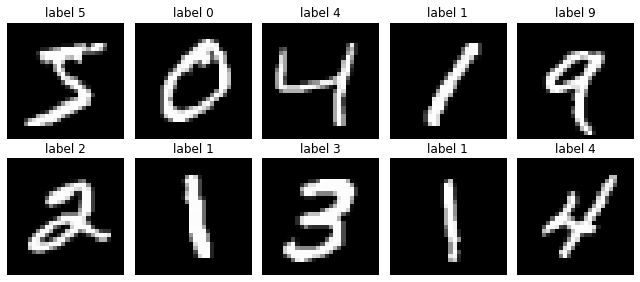

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, i in zip(axes.ravel(), range(10)):
    img, lbl = train_full[i]
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(f"label {lbl}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Architecture — the 784 → 256 → 128 → 10 MLP from the lesson

In [4]:
class MnistMLP(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.net(x)

model = MnistMLP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

parameters: 235,146


## 4. Training loop with early stopping
Loss: `CrossEntropyLoss` (expects *logits* — no softmax in the final layer, see pitfall #2). Optimizer: Adam.

In [5]:
BATCH = 256
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

def run_epoch(model, loader, loss_fn, opt=None):
    is_train = opt is not None
    model.train(is_train)
    total_loss, total_correct, total_n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss   = loss_fn(logits, y)
        if is_train:
            opt.zero_grad(); loss.backward(); opt.step()
        total_loss    += loss.item() * len(y)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_n       += len(y)
    return total_loss / total_n, total_correct / total_n

def train_model(model, n_epochs=4, lr=1e-3, weight_decay=1e-4, patience=2):
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    best_val, best_state, waited = float("inf"), None, 0
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, loss_fn, opt)
        va_loss, va_acc = run_epoch(model, val_loader,   loss_fn, None)
        dt = time.time() - t0
        history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va_loss, "val_acc": va_acc, "dt": dt})
        print(f"epoch {epoch}  train_loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} acc={va_acc:.4f}  ({dt:.1f}s)")
        if va_loss < best_val - 1e-4:
            best_val   = va_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            waited     = 0
        else:
            waited += 1
            if waited >= patience:
                print(f"early stopping at epoch {epoch}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return history

history = train_model(model, n_epochs=4)

epoch 1  train_loss=0.5104 acc=0.8534  val_loss=0.2273 acc=0.9320  (7.0s)
epoch 2  train_loss=0.2019 acc=0.9404  val_loss=0.1522 acc=0.9538  (7.2s)
epoch 3  train_loss=0.1427 acc=0.9578  val_loss=0.1196 acc=0.9638  (7.0s)
epoch 4  train_loss=0.1131 acc=0.9660  val_loss=0.1079 acc=0.9678  (7.1s)


## 5. Final evaluation on the test set

In [6]:
loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = run_epoch(model, test_loader, loss_fn, None)
print(f"test loss = {test_loss:.4f}   test accuracy = {test_acc:.4f}")

test loss = 0.0963   test accuracy = 0.9703


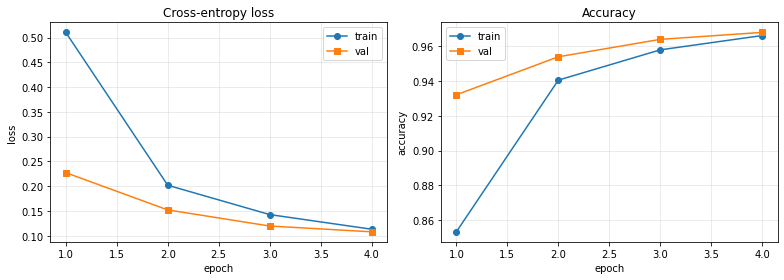

In [7]:
# Loss curves
epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, [h["train_loss"] for h in history], "o-", label="train")
axes[0].plot(epochs, [h["val_loss"]   for h in history], "s-", label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.3); axes[0].legend()
axes[0].set_title("Cross-entropy loss")
axes[1].plot(epochs, [h["train_acc"] for h in history], "o-", label="train")
axes[1].plot(epochs, [h["val_acc"]   for h in history], "s-", label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].grid(alpha=0.3); axes[1].legend()
axes[1].set_title("Accuracy")
plt.tight_layout(); plt.show()

## 6. Confusion matrix
Where does the model still fail? Expect ~97% accuracy to still confuse 4↔9, 3↔8, 5↔6.

In [8]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x.to(DEVICE))
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(y.numpy())
preds = np.concatenate(all_preds); labels = np.concatenate(all_labels)

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(labels, preds):
    cm[t, p] += 1

per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(per_class_acc):
    print(f"class {i}: n={cm.sum(axis=1)[i]:>5}  accuracy={acc:.3f}")

class 0: n=  980  accuracy=0.991
class 1: n= 1135  accuracy=0.989
class 2: n= 1032  accuracy=0.979
class 3: n= 1010  accuracy=0.956
class 4: n=  982  accuracy=0.962
class 5: n=  892  accuracy=0.976
class 6: n=  958  accuracy=0.981
class 7: n= 1028  accuracy=0.964
class 8: n=  974  accuracy=0.954
class 9: n= 1009  accuracy=0.948


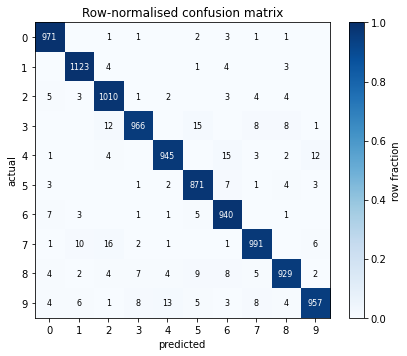

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Row-normalised confusion matrix")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=8)
plt.colorbar(im, ax=ax, label="row fraction"); plt.tight_layout(); plt.show()

## 7. Peek at the mistakes
Show 12 images where the model was wrong — often visually ambiguous digits.

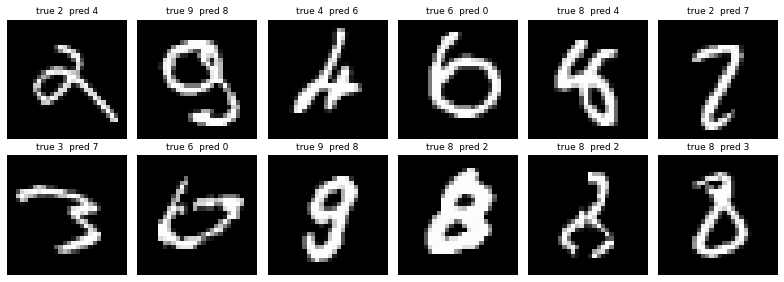

In [10]:
wrong_idx = np.where(preds != labels)[0][:12]
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, idx in zip(axes.ravel(), wrong_idx):
    img, _ = test_set[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"true {labels[idx]}  pred {preds[idx]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 8. Boss gates (quick checks)

In [11]:
assert test_acc >= 0.95,    f"boss gate: test accuracy >= 0.95 (got {test_acc:.3f})"
assert n_params < 300_000,  "boss gate: MLP must stay under 300k parameters"
assert cm.sum() == len(test_set), "confusion matrix must cover every test sample"
# No class should collapse completely
assert per_class_acc.min() > 0.90, f"every digit must beat 90% (worst got {per_class_acc.min():.2f})"
print("All boss gates passed.")

All boss gates passed.


## 9. Self-assessment quiz

1. You increase the batch size from 32 to 512. What typically happens to (a) time per epoch, (b) gradient noise, (c) learning-rate choice?
2. Does going from 3 hidden layers to 10 help on MNIST? Try it by adding more `Linear(128, 128) + ReLU + Dropout` blocks.
3. Compare dropout 0.5 vs 0.2 on (a) this 235k-parameter MLP and (b) a tiny 1k-parameter MLP. Which is more appropriate for each?
4. Swap `nn.CrossEntropyLoss()` for `nn.NLLLoss()` + `nn.LogSoftmax(dim=1)` as the last layer. Does the accuracy change? What pitfall does this scenario illustrate?
5. You forget `model.eval()` before evaluation. Which number in the report becomes wrong, and why?

<details>
<summary>Hints for the answers</summary>

1. (a) time per epoch drops because more GPU/CPU-parallelism per step; (b) each gradient is averaged over more samples, so noise goes *down*; (c) the effective "noise temperature" is lower, so you usually need a larger learning rate — the classic linear-scaling rule.
2. On MNIST, the extra depth rarely helps without tricks (residuals, better init, batchnorm). The vanishing-gradient chapter from lesson 3-3 explains why.
3. Dropout 0.5 is sensible for large/over-parameterised nets; it wrecks a 1k-parameter network that has nothing to spare.
4. Numerics stay correct, but you have now applied `log_softmax` before `NLLLoss`, which expects log-probs. If you *also* left softmax in the model, you would be applying softmax twice — the pitfall the theory warns about.
5. Dropout is still active in train mode, so the logits are noisy → test accuracy becomes artificially worse. (Batch-norm running stats would also be affected, but this MLP has no batch-norm.)
</details>

## 10. Stretch: CNN upgrade
The lesson suggests replacing the first two Linear layers with convolutions. Here's the architecture; run it overnight on a bigger machine if you want to chase > 99%.

In [12]:
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.head(self.feat(x))

# Only show the architecture + parameter count; skip training by default.
cnn = MnistCNN()
print(f"CNN parameters: {sum(p.numel() for p in cnn.parameters()):,}")
print("To train, set RUN_CNN=True below.")
RUN_CNN = False
if RUN_CNN:
    cnn = MnistCNN().to(DEVICE)
    _ = train_model(cnn, n_epochs=3, lr=1e-3)
    loss_cnn, acc_cnn = run_epoch(cnn, test_loader, loss_fn, None)
    print(f"CNN test acc: {acc_cnn:.4f}")

CNN parameters: 421,642
To train, set RUN_CNN=True below.


## 11. Wrap-up for Level 3

What you now have:
- A hand-traced view of what `torch.autograd` does under the hood.
- A working end-to-end training pipeline (data → model → loss → optimizer → evaluation).
- Three regularization tools you can pull off the shelf.
- A real model that classifies real digits above 95% accuracy.

Next (Level 4+): sequences, attention, Transformers — the doorway to modern LLMs.

## References
- Source theory: [`3-5-image-classifier-boss.mdx`](../../llm-quest-theory/level-3/3-5-image-classifier-boss.mdx)
- Moving on: [Level 4](../level-4/README.md) — RNNs, self-attention, Transformer fundamentals.